# In Silico Mechanobiological Modeling of Bone Fracture Healing: Simulating Circadian Weight-Bearing cycles and Cellular Tissue Differentiation

**Author:** Simon Weissberg  
**Course:** Numerical Methods
**Date:** May 2026  

---

## 1. Introduction and Background

### Motivation
Bone fracture healing is a complex physiological process involving coordinated interactions between biological signaling networks, cellular migration, and mechanical environments. In clinical orthopedics, managing mechanical loading is very important for avoiding complications like delayed unions or non-unions which could potentially require surgical intervention.

While mechanical stability promotes early cellular anchoring, progressive weight-bearing forces are required to stimulate calcification and healing at the fracture site. Investigating these mechanics *in vivo* presents ethical and logistical challenges for researchers. Consequently, *in silico* computational simulations can be a great resource for predicting healing timelines, mapping tissue progression, and optimizing patient-specific rehabilitation protocols.

### Context and Literature Gap
Current tissue differentiation models typically rely on continuous loading profiles, constant force, that assume a constant mechanical environment. This approach creates a significant difference between computational models and actual human physiology, the circadian day/night rhythm of activity and physiological rest being just one of them. Furthermore, existing clinical software can, at times, lack intuitive, multi-planar visualization tools which can make it hard to trace localized mechanical changes in bone over time. 

This work attempts to partly address some of these limitations by introducing a lattice-based simulation model that explicitly incorporates circadian loading patterns and progressive weight-bearing milestones across a multi-month recovery timeline.

### Project Goals
The primary objective of this software is to simulate the progression of tissue differentiation within a 3D fracture gap. The simulation explicitly performs these functions:
1. Models cell migration into the injury zone via a finite-difference implementation of the diffusion equation.
2. Calculates multi-axial mechanical strain patterns resulting from weight-bearing activity.
3. Implements a biophysical rule-of-mixtures decision framework to continuously update local structural stiffness ($E$).
4. Provides an interactive dual-panel dashboard to visually track the healing front and local mechanical properties across the healing timeline.

## 2. Methods

### Lattice Initialization and Spatial Discretization
The structural domain is discretized into a 3D voxel lattice matrix with an artificial cubic geometry with an isotropic voxel size $\Delta x = 1.0 \text{ mm}$. Each coordinates point $(x, y, z)$ represents a four-dimensional state vector mapping the point's mechanobiological variables:

$$\mathbf{U}(x,y,z) = [S, \, n, \, E, \, k]^T$$

Where $S$ is the mechanical regulatory stimulus, $n$ is the cellular density, $E$ is the localized Young's Modulus (MPa), and $k$ represents tissue permeability.

The artificial configuration models two intact cortical bone segments flanking a fracture gap initialized entirely with soft granulation tissue.

### Biological Physics: Cellular Diffusion Mechanics
Mesenchymal stem cell migration from the healthy bone borders into the unpopulated fracture zone is modeled with the diffusion equation used in (Lacroix et al, 2002b):

$$\frac{\partial n}{\partial t} = D \cdot \nabla^2 n$$

Where $D$ is in $\text{ mm}^2/\text{day}$ in this simulation representing the spatial diffusion coefficient. I implement this numerically using scipy.ndimage.laplace to calculate the movement of cells at each time step:

In [1]:
n = bone_data[:, :, :, 1]
    
# Standard diffusion calculation
dn_dt = D * laplace(n)
n_new = n + dn_dt * dt

NameError: name 'bone_data' is not defined

### Mechanical Fields and Strain Mechanics
An axial loading vector $\mathbf{F} = [F_x, F_y, F_z]^T$ is distributed evenly over the cross-sectional area of each voxel $A = (\text{Voxel Size})^2$ that aligns with that component of the force, yielding axial stress $\sigma_z = F_i / A_i$. Localized strain components are updated dynamically based on the current local stiffness field $E_{i,j,k}$:

$$\epsilon_x = \frac{1}{E_{i,j,k}} \left[ \sigma_x - \nu(\sigma_y + \sigma_z) \right]$$

$$\epsilon_y = \frac{1}{E_{i,j,k}} \left[ \sigma_y - \nu(\sigma_x + \sigma_z) \right]$$

$$\epsilon_z = \frac{1}{E_{i,j,k}} \left[ \sigma_z - \nu(\sigma_x + \sigma_y) \right]$$

The cell-level mechanical regulatory stimulus $S$ is derived from the octahedral shear strain $\gamma_{\text{oct}}$, normalized by an empirical scaling parameter $a = 0.0375$:

$$\gamma_{\text{oct}} = \frac{2}{3}\sqrt{(\epsilon_x - \epsilon_y)^2 + (\epsilon_y - \epsilon_z)^2 + (\epsilon_z - \text{x})^2}$$

$$S_{i,j,k} = \frac{\gamma_{\text{oct}}}{a}$$



In [ ]:
area = voxel_size**2
    sigma = force_vec / area
    nu = 0.3 
    
    eps_x = (1/E_current) * (sigma[0] - nu*(sigma[1] + sigma[2]))
    eps_y = (1/E_current) * (sigma[1] - nu*(sigma[0] + sigma[2]))
    eps_z = (1/E_current) * (sigma[2] - nu*(sigma[1] + sigma[0]))
    

    diff_sq = (eps_x - eps_y)**2 + (eps_y - eps_z)**2 + (eps_z - eps_x)**2
    gamma_oct = (2/3) * np.sqrt(diff_sq)
    S = gamma_oct / a_param # shortened form, not accounting for fluid flow in bone.
    bone_grid[:, :, :, 0] = S

With Stimulus determined, np.select is then used to assign the target properties of the cells which are differentiating in each voxel. 

In [ ]:
# --- PART 3: DIFFERENTIATION (Using np.select) ---
    # Define the masks for each tissue type
    conds = [
        (S >= 3.0),                               # Fibrous
        (S >= 1.0) & (S < 3.0),                   # Cartilage
        (S >= 0.01) & (S < 1.0) & (n > 0.6),      # Mature Bone
        (S >= 0.01) & (S < 1.0) & (n <= 0.6),     # Immature Bone
        (S < 0.01)                                # Marrow
    ]
    
    # Define the target values for E and Permeability
    targets_E = [
        PROPERTIES['fibrous']['E'],
        PROPERTIES['cartilage']['E'],
        PROPERTIES['mature_bone']['E'],
        PROPERTIES['immature_bone']['E'],
        PROPERTIES['marrow']['E']
    ]
    
    targets_K = [
        PROPERTIES['fibrous']['perm'],
        PROPERTIES['cartilage']['perm'],
        PROPERTIES['mature_bone']['perm'],
        PROPERTIES['immature_bone']['perm'],
        PROPERTIES['marrow']['perm']
    ]
    
    # np.select matches the condition to the target value across the whole grid
    target_E_grid = np.select(conds, targets_E, default=PROPERTIES['granulation']['E'])
    target_K_grid = np.select(conds, targets_K, default=PROPERTIES['granulation']['perm'])

### Tissue Differentiation Rule of Mixtures
With the target states determined, the expected properties are determined using the rule of mixing used by Lacroix and are progressivly evolved toward using the rate constant $\alpha = 0.0027$ (Lacroix et al, 2002b):

$$E_{\text{mix}} = \left(\frac{n}{n_{\text{max}}}\right) E_{\text{target}} + \left(1 - \frac{n}{n_{\text{max}}}\right) E_{\text{granulation}}$$

$$E^{t+\Delta t}_{i,j,k} = E^t_{i,j,k} + \alpha \left( E_{\text{mix}} - E^t_{i,j,k} \right)$$



### Day night cycle Loading Logic
The applied compressive force $F$ follows a conditional progression, combining progressive loading stages with day/night rest cycles:

$$F_{\text{base}} = \begin{cases} -0.15\text{ N} & \text{if } \text{day} < 30 \\ -10.0\text{ N} & \text{if } 30 \leq \text{day} < 60 \\ -80.0\text{ N} & \text{if } 60 \leq \text{day} < 90 \\ -110.0\text{ N} & \text{if } \text{day} \geq 90 \end{cases}$$

$$F_z(t) = \begin{cases} F_{\text{base}} & \text{if } (\text{hour} \pmod{24}) \leq 16 \quad \text{(Active Daytime)} \\ -0.15\text{ N} & \text{if } (\text{hour} \pmod{24}) > 16 \quad \text{(Night Rest)} \end{cases}$$


### Constants

The constants were adjusted for complete bone healing over 16 weeks as they were in Lacroix and Pendergast's research on fracture healing in 2002 (Lacroix et al, 2002a).

In [ ]:
# --- TISSUE PROPERTIES ---
PROPERTIES = {
    'cortical_bone': {'E': 20000, 'perm': 1e-17,  'nu': 0.3},
    'mature_bone':   {'E': 6000,  'perm': 3.7e-13, 'nu': 0.3},
    'immature_bone': {'E': 1000,  'perm': 1e-13,   'nu': 0.3},
    'marrow':        {'E': 2,     'perm': 1e-14,   'nu': 0.17},
    'cartilage':     {'E': 10,    'perm': 5e-15,   'nu': 0.17},
    'fibrous':       {'E': 2,     'perm': 1e-14,   'nu': 0.17},
    'granulation':   {'E': 1,     'perm': 1e-14,   'nu': 0.17}
}

a_param = 0.0375  
n_max = 1.0     

# --- Fracture Properties ---

frac_youngs_modulus = 1.0  # MPa, for the initial granulation tissue in the fracture gap
frac__permeability = 1e-14    # m^2, for the initial granulation tissue in the fracture gap
frac_cell_density = 0.1      # Initial cell density in the fracture gap (0 to 1 scale)
gap = 5                     # Number of voxels representing the fracture gap (total width)

# --- Normal Bone Properties ---
normal_bone_E = 20000        # MPa, Young's modulus for cortical bone
normal_bone_perm = 1e-17     # m^2, permeability for cortical
normal_cell_density = 1.0       # Fully populated with cells (0 to 1 scale)

# --- SIMULATION CONFIGURATION ---
size = 50           # Grid dimensions (50x50x50). Runtime is very dependent on this value. Adjust as needed for testing or higher resolution.
voxel_size = 1.0    # 1mm voxels
num_days = 112        # Total simulation time in days
num_hours = num_days * 24       # Simulation duration in hours
save_interval = 1  # How often to take a snapshot for the visualizer. 1 means each day.


# Applied Force: We will simulate gradual loading during healing by increasing the applied force over time to reflect the natural process of weight-bearing and rehabilitation.

applied_force = np.array([0, 0, 0], dtype=float)  # Initial force vector (Fx, Fy, Fz) in Newtons. We will update the components during the simulation to simulate loading during healing.

#___ Loading and Activity Pattern Constants ___

low_force = -0.15  # N, representing the initial rest period immediately after a fracture (e.g., during sleep or immobilization)
early_healing_force = -10  # N, representing the moderate force during the early healing phase when the patient starts to bear weight
mid_healing_force = -80  # N, representing the increased force during the mid-healing phase as the patient becomes more active
late_healing_force = -110  # N, representing the higher force during the late healing phase as the bone regains strength and the patient returns to normal activities

# ___ Movement constants ___
D = 10  # Diffusion coefficient for cell migration (mm^2/day). The value of D is a rough estimate based on the scale of the simulation and the expected rate of cell migration during bone healing. It can be adjusted based on experimental data or literature values for specific cell types involved in the healing process.
dt = 1.0/24   # Time step for the simulation (1 hour in days)

# ___ Differentiation update constant ___
alpha = 0.0027  # How quickly the tissue properties update towards the target values (0 < alpha <= 1, where 1 means instant update). Prevents sudden jumps in E and permeability, creating a more gradual healing process.
                # calibrated to allow for a realistic healing timeline of around 3-4 months in the simulation, which matches clinical observations of bone healing in humans.

## 3. Results

### Verification and Validation Metrics
To confirm model correctness and algorithm stability, automated unit tests were executed via the test framework suite. The verification evaluated three criteria:
1. **Geometric Integrity**: Confirmed that dimensions initialized correctly to $50 \times 50 \times 50 \times 4$.
2. **Cell Volume Conservation**: Ensured cell concentrations remained strictly bounded within physical boundaries $[0.0, 1.0]$.
3. **Physics Baseline Validation**: Confirmed that running a zero-load vector ($\mathbf{F} = [0,0,0]$) resulted in an evaluated regulatory stimulus of exactly $S = 0.0$ across all matrix nodes, verifying that non-physical artifacts were not introduced by the stress formulas.

The validation architecture confirmed model reliability:
`Ran 3 tests in 0.002s | Status: OK`

In addition, comparison of the timeline of bone healing in this simulation aligns with the timetable for healing of 16 weeks established in (Lacroix et al, 2002a). This, along with the check above which appear to show that conservation laws have been obeyed, I believe my simulation is working correctly.



## Outputs

My code produces an interactive animation which allows for switching between viewing cell density and Young's modulus. Additionally, It produces graphs which plot the cell density and Young's modulus of a point at the center of the fracture over the time of the simulation. For the purposes of this report, the graphs may be more meaningful, so I am just showing them, but the full interctive animation can be viewed by just running main.py in the code. 

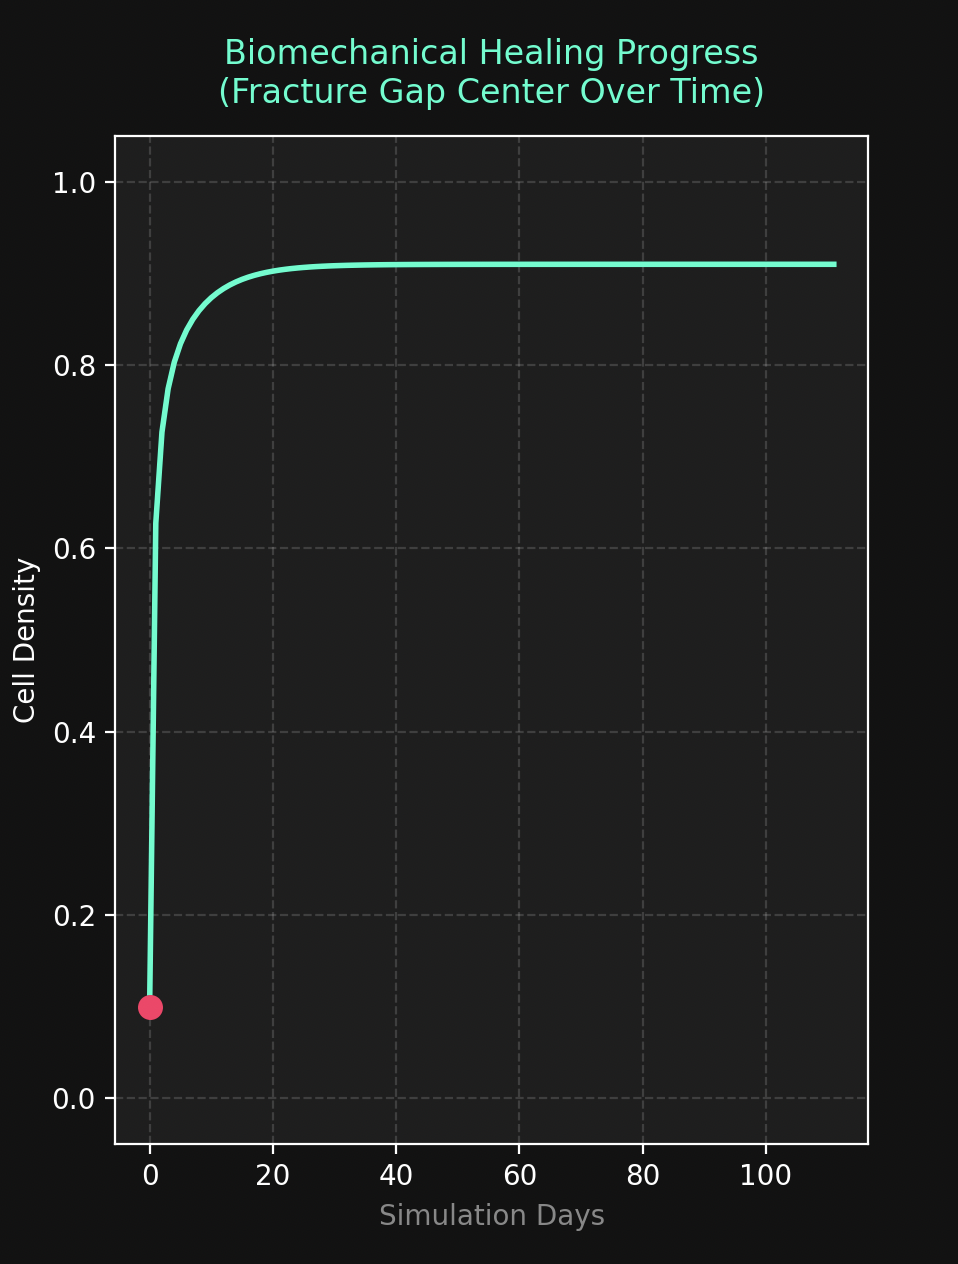

## Figure 1


Shown here is the cell density vs day of the simulation. It can be seen that the cells very quickly migrate into the fracture at the beginning of the simulation and their density remains largely unchanged throughout the remainder. In real life, the migration of new cells to the injury site is one of the quickest parts of fracture healing. Damaged and dead cells release factors which produce local inflamation: stimulating the production of new bloodcells, and attracting new cells to begin differentiating at the fracture sight and begin rebuilding the bone. Modifying the D value, which is currently set at 10, would cause this graph to plateau earlier if it is increased and later if it is decreased. The current value of D is scaled to approximately match the millimeter scale of the simulation.

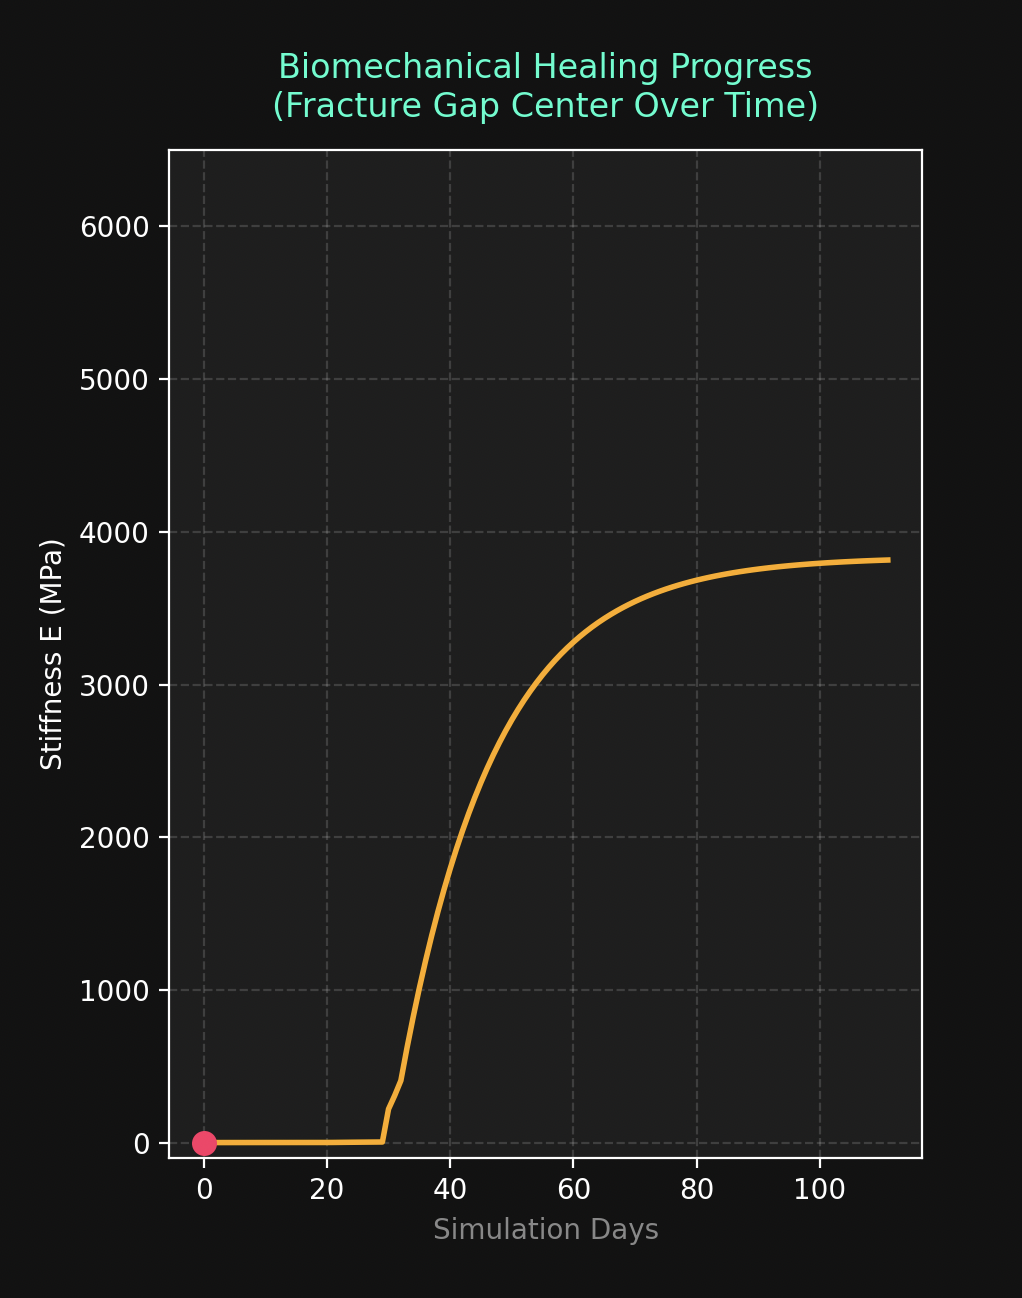

## Figure 2

Shown here is the Young's modulus vs day of the simulation. In contrast to the cell density, the Young's modulus remains flat until approximately 30 days into the simulation. After this point, it begins a rapid increase until it flattens out at approximately 3,812 MPa at the end of the simulation. This aligns with the expected amount of time it would take for a bone in this scenario. In normal bone healing, there are examples of this kind of refractory period before healing begins to progress. There is a period during which new cells are migrating to the fracture site aswell as new blood vessels are being developed around the fracture site to support the high demands of bone remodeling, referred to as angiogenesis. While this figure looks at the Young's modulus at a very large scale, of 6000, during this apparently "flat" period, there are small increases to the Young's modulus which are taking place. This is demonstrated in Figure 3.

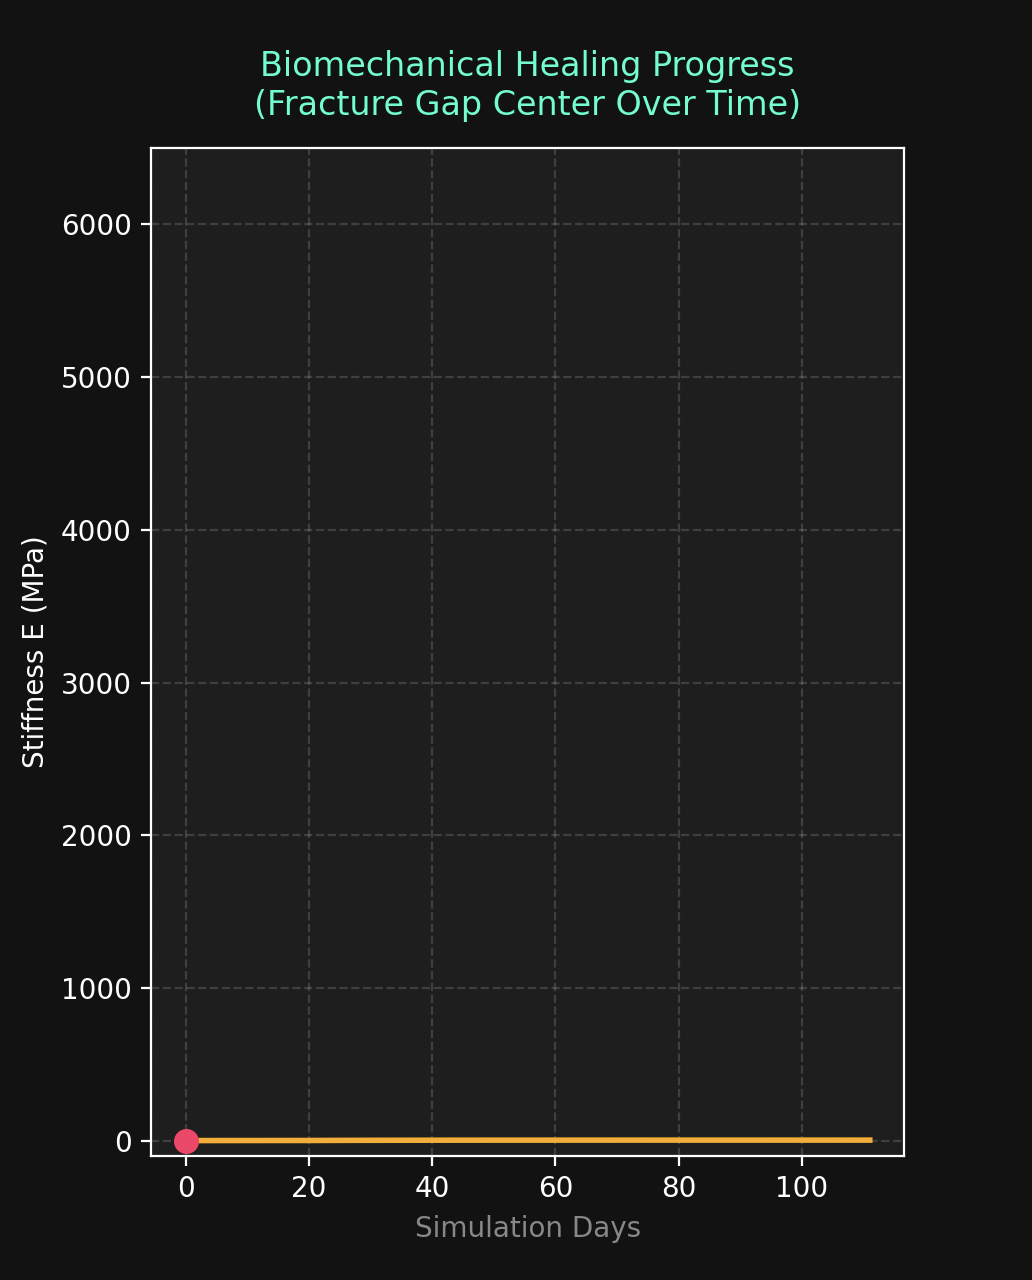

## Figure 3

Here is an example of the output you get if you change the the daytime loading on the bone during the early stage of healing to zero in the simulation. You see that the bone in the fracture site will become "stuck" in its broken state and will not be able to heal. During this 30 day rest period, the bone is undergoing small, but not insignificant, changes under the very low stimulus which will later on allow it to handle the higher stresses during the later stages of rehabilitation. Without this low weight early stage, the granulation tissue at the fracture site will not be able to take the stress. This demonstrates an important aspect of bone healing. If an individual never puts weight on a broken bone, this can hurt their recovery just as much as putting too much weight on it and leave them at risk of new fractures in the same area.

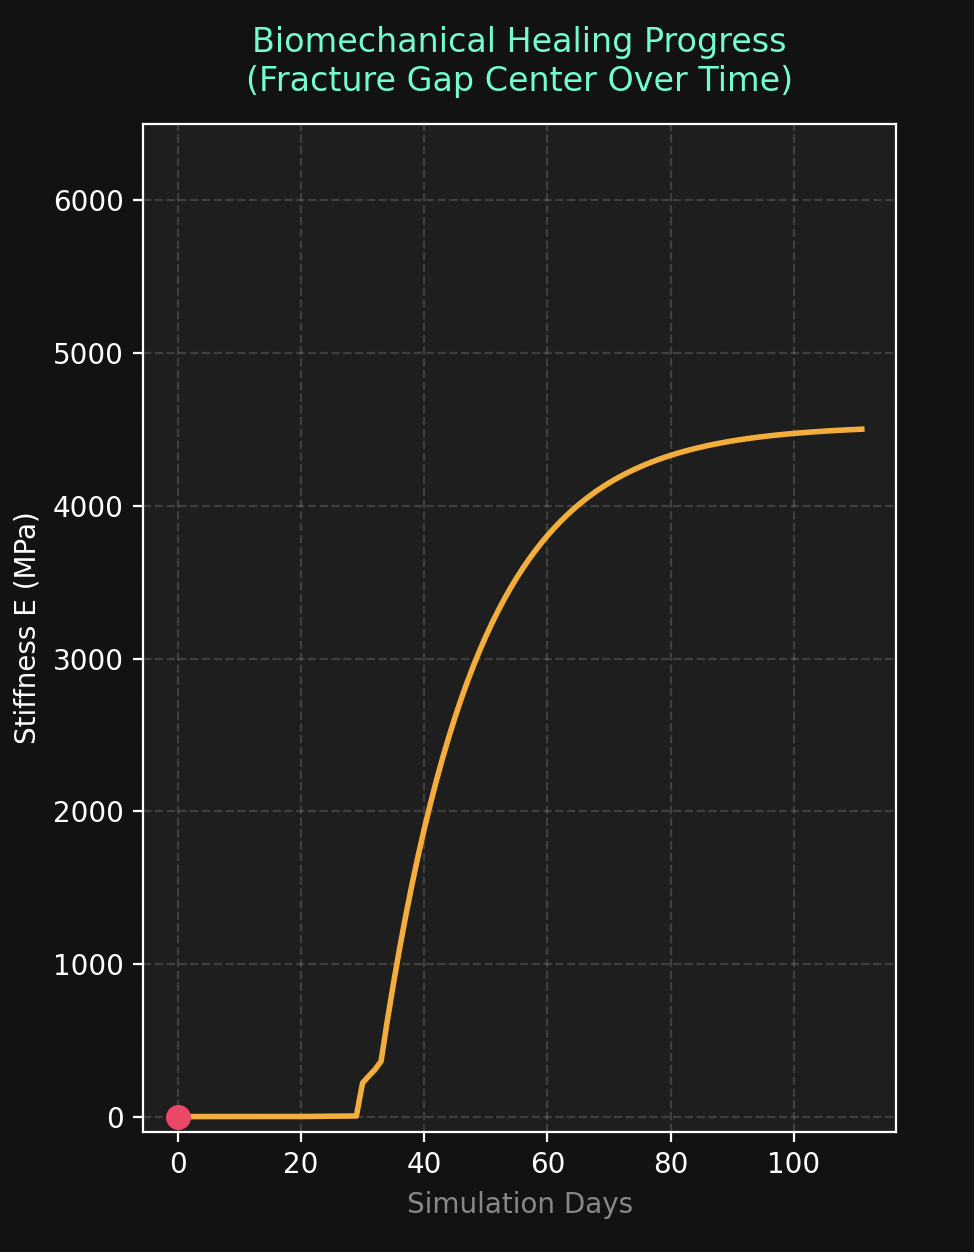

## Figure 4

An additional aspect I want to demonstrate is the effect of how much exercise the individual partakes in on their final bone density. Shown here is the same situation as in Figure 2 but with one modification. While in Figure 2, the individual sleeps for 8 hours every night; in Figure 4, the individual sleeps for only 5 hours every night. This has an end result of the gap at the center of the fracture ending the simulation with a Young's modulus of approximately 4,501 MPa, 689 MPa greater than the final value in Figure 2. This has clear examples in real life. Someone who exercises more often will put greater strain on their bone which will subsequently produce greater stimulation for bone remodelling. This has an end result of this indivudal having denser bones than an individual who exercises less often. This simulation shows that the reason for this difference lies, at least in part, in the amount of stimulation these individual's bones are receiving which is a very important part of the science behind exercise and it benefits.

## 4. Disscusion

### Interpretation inside Mechanobiological Context
The model matches what I would expect according to established orthopedic clinical benchmarks, showing the bone in the gap clearly "filling in" over the period of the simulation in the fracture gap. Incorporating Day night cycles introduced a realistic rest window which I think makes this model slightly more accurate. In actual patients, this kind of resting period limits over-straining during sleep hours, allowing cell populations to diffuse and establish structural anchors before undergoing day-time load adjustments. An interesting behavior that this addition to the code created was that the bone, even at the end of healing, did not reach the maximum Young's modulus which would have been possible for it. I think this behavior has some real world examples in the case of real world individuals. Bone strength is dependent on our levels of activity and lower activity can mean lower bone density than is potentially possible. 

### Methodological Strengths and Limitations
The primary strength of this simulation lies in its vectorization for increased performance and its modular architecture. By mapping discrete material behaviors onto vector arrays via `np.select`, the model eliminates the need for expensive nested loops, keeping calculation times minimal. 

However, a key limitation is the simplified linear calculation of strain. The model currently calculates mechanical strain using a simple axial load assumption, which ignores fluid flow effects within the bone pores (poroelasticity) as well as complex shear forces from bending or twisting. Currently, the simulation calculates K, the permeability, at each time step but it is never used. Without this factor being implemented, the simulation is missing a major part of our bone anatomy, especially at a fracture site. While it might be tempting to imagine bone much in the same way as a rock, there is extracellular fluid throughout your bones which allow for cells to receive vital things like nutrients. These factors are even more important in fractures, where there is inflammation cause there to be even more fluid than usual. A point of further research could be in expanding the simulation scope to model these fluids as well as the elastic behaviors of the bone and, additionally, the migration of new cells into the fracture after the intial stage of healing. 

Additionally, I wish there would have been a better real world reference that I could have used to compare the accuracy of the model to. While the 16 weeks for heal timeline is a good bench mark, it does not necissarily mean that my model is being entirely accurate to the inbetween stages of bone healing. My model's functionally was also very dependent on how the variables I used where calibrated. I would have liked to better understand why the constants I used worked beyond just many iterations of trial and error which went into them.

I also would have liked to include the movement of fluids like extracellular fluid around the cells within the bone, but this was not possible in the available time. I believe this does take away from the model's ability to represent real world bone healing

### Encountered Engineering Challenges
A point of major difficulty during the final stages of making this simulation was the calibration of constants. The bone in the fracture could very easily never begin healing if the applied force or constants like D where even slightly off. These kinds of things can be supprisingly important in simulations like this with so many moving parts.

## 5. Conclusion

### Summary of Accomplishments
This project successfully implemented a 3D voxel based simulation of bone fracture healing under dynamic loading. The software combines cell diffusion mechanics with local stress-strain relationships and Day-Night activity patterns, providing an interactive visualization dashboard to track healing progress.

### Future Software Extensions
Future development will focus on expanding the physics engine to support irregular structural domains derived from clinical CT scans (DICOM imports). Additionally, expanding the mechanics framework to include solving for fluid flow and pressure will allow the software to capture fluid-structure interactions, significantly improving its predictive accuracy for real-world clinical applications.

---

## 6. Literature References

Huiskes, R., Van Driel, W. D., & Prendergast, P. J. (1997). A biomechanical regulatory model for periprosthetic fibrous-tissue differentiation. Journal of Materials Science: Materials in Medicine, 8, 785–788.

Komarova, S. V., et al. (2003). Mathematical model predicts a critical role for osteoclast autocrine regulation in the control of bone remodeling. Bone, 33(2), 206-215.

Lacroix, D., & Prendergast, P. J. (2002). A mechano-regulation model for tissue differentiation during fracture healing: analysis of gap size and loading. Journal of Biomechanics, 35(9), 1163-1171.

Lacroix, D., Prendergast, P.J., Li, G. et al. (2002). Biomechanical model to simulate tissue differentiation and bone regeneration: Application to fracture healing. Medical & Biological Engineering & Computing . 40, 14–21.


---

## Disclosure of LLM Usage
Generative Artificial Intelligence systems were utilized during the development and writing stages of this project. Specifically, the Gemini 3 Flash model was used to assist in the vectorizing of the original code along with enhancing the efficiency and run time of the code along with creating the docuentation for the code. Additionally, It was used in creating the figures and animations, setting up Python `unittest` structural frameworks, and formatting the Matplotlib interactive dashboard. It was also used to help improve the general readibilty of the code, and it has helped extensively in debugging. 

For the writing of this report, it has been used to help with proof reading along with suggesting changes.

After using these tools, I have reviewed and edited the content of this report and the code in my repository to ensure it reflects my own understanding and work. 